In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/data_macro.csv", parse_dates=["Date"])
df = df.sort_values(["Date", "ticker"]).reset_index(drop=True)

HORIZONS = [3, 5, 10, 30]

FEATURES = [col for col in df.columns if col not in
            ["Date", "ticker", "target_3d", "target_5d",
             "target_10d", "target_30d", "target_90d", "target_365d"]]

train = df[df["Date"] < "2023-01-01"]
test  = df[df["Date"] >= "2023-01-01"]

print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Признаков: {len(FEATURES)}")
print(f"\nМакропризнаки: {[f for f in FEATURES if any(f.startswith(p) for p in ['brent_', 'usdrub_', 'imoex_'])]}")

Train: 25200, Test: 12403
Признаков: 49

Макропризнаки: ['brent_return_1d', 'brent_return_5d', 'brent_return_20d', 'brent_to_ma20', 'brent_vol_10d', 'usdrub_return_1d', 'usdrub_return_5d', 'usdrub_return_20d', 'usdrub_to_ma20', 'usdrub_vol_10d', 'imoex_return_1d', 'imoex_return_5d', 'imoex_return_20d', 'imoex_to_ma20', 'imoex_vol_10d']


In [3]:
def get_models():
    return {
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="mlogloss", random_state=42, n_jobs=-1
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42, n_jobs=-1, verbose=-1
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            auto_class_weights="Balanced",
            random_seed=42, verbose=0
        )
    }

label_map = {0: -1, 1: 0, 2: 1}

results = {}

for h in HORIZONS:
    results[h] = {}
    target = f"target_{h}d"

    y_train_xgb   = train[target]
    y_test_xgb    = test[target]
    y_train_other = train[target].map(label_map)
    y_test_other  = test[target].map(label_map)

    X_train = train[FEATURES]
    X_test  = test[FEATURES]

    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train_xgb)
    weight_dict = dict(zip(classes, weights))
    sample_weights = y_train_xgb.map(weight_dict)

    models = get_models()

    for name, model in models.items():
        print(f"  Обучаю {name} горизонт {h}д...")

        if name == "XGBoost":
            model.fit(X_train, y_train_xgb,
                     sample_weight=sample_weights, verbose=False)
            y_pred = model.predict(X_test)
            f1 = f1_score(y_test_xgb, y_pred, average="macro")
        else:
            model.fit(X_train, y_train_other)
            y_pred = model.predict(X_test)
            f1 = f1_score(y_test_other, y_pred, average="macro")

        results[h][name] = round(f1, 4)
        print(f"    F1 macro: {f1:.4f}")

print("\nГотово!")

  Обучаю XGBoost горизонт 3д...
    F1 macro: 0.3729
  Обучаю LightGBM горизонт 3д...
    F1 macro: 0.3745
  Обучаю CatBoost горизонт 3д...
    F1 macro: 0.3616
  Обучаю XGBoost горизонт 5д...
    F1 macro: 0.3835
  Обучаю LightGBM горизонт 5д...
    F1 macro: 0.3974
  Обучаю CatBoost горизонт 5д...
    F1 macro: 0.3692
  Обучаю XGBoost горизонт 10д...
    F1 macro: 0.3871
  Обучаю LightGBM горизонт 10д...
    F1 macro: 0.3980
  Обучаю CatBoost горизонт 10д...
    F1 macro: 0.3938
  Обучаю XGBoost горизонт 30д...
    F1 macro: 0.3491
  Обучаю LightGBM горизонт 30д...
    F1 macro: 0.3511
  Обучаю CatBoost горизонт 30д...
    F1 macro: 0.3552

Готово!


In [4]:
# Результаты без макро (из ноутбука 08)
f1_without_macro = {
    3:  {"XGBoost": 0.3722, "LightGBM": 0.3727, "CatBoost": 0.3659},
    5:  {"XGBoost": 0.3667, "LightGBM": 0.3627, "CatBoost": 0.3666},
    10: {"XGBoost": 0.3541, "LightGBM": 0.3565, "CatBoost": 0.3648},
    30: {"XGBoost": 0.3455, "LightGBM": 0.3476, "CatBoost": 0.3412},
}

print("Сравнение F1 macro — без макро vs с макро:")
print(f"\n{'Горизонт':<12} {'Модель':<12} {'Без макро':<12} {'С макро':<12} {'Прирост'}")
print("-" * 55)

for h in HORIZONS:
    for name in ["XGBoost", "LightGBM", "CatBoost"]:
        old = f1_without_macro[h][name]
        new = results[h][name]
        diff = new - old
        sign = "+" if diff >= 0 else ""
        print(f"{h} дней{'':<6} {name:<12} {old:<12} {new:<12} {sign}{diff:.4f}")
    print()

Сравнение F1 macro — без макро vs с макро:

Горизонт     Модель       Без макро    С макро      Прирост
-------------------------------------------------------
3 дней       XGBoost      0.3722       0.3729       +0.0007
3 дней       LightGBM     0.3727       0.3745       +0.0018
3 дней       CatBoost     0.3659       0.3616       -0.0043

5 дней       XGBoost      0.3667       0.3835       +0.0168
5 дней       LightGBM     0.3627       0.3974       +0.0347
5 дней       CatBoost     0.3666       0.3692       +0.0026

10 дней       XGBoost      0.3541       0.3871       +0.0330
10 дней       LightGBM     0.3565       0.398        +0.0415
10 дней       CatBoost     0.3648       0.3938       +0.0290

30 дней       XGBoost      0.3455       0.3491       +0.0036
30 дней       LightGBM     0.3476       0.3511       +0.0035
30 дней       CatBoost     0.3412       0.3552       +0.0140



Лучшая модель с макро: LightGBM
Средний F1: {'XGBoost': 0.37315, 'LightGBM': 0.38025000000000003, 'CatBoost': 0.36994999999999995}


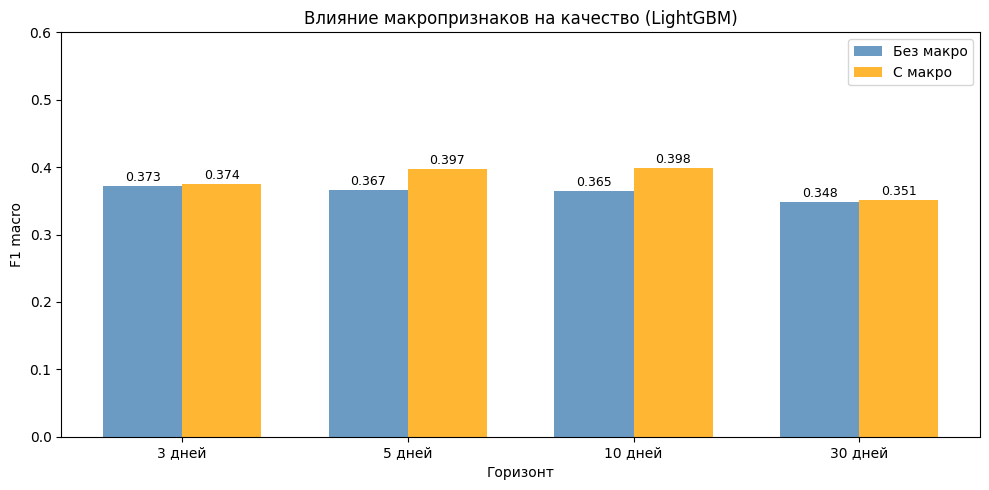

In [5]:
# Берём лучшую модель по среднему F1
avg_by_model = {}
for name in ["XGBoost", "LightGBM", "CatBoost"]:
    avg_by_model[name] = np.mean([results[h][name] for h in HORIZONS])

best_model = max(avg_by_model, key=avg_by_model.get)
print(f"Лучшая модель с макро: {best_model}")
print(f"Средний F1: {avg_by_model}")

# График
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS))
width = 0.35

old_vals = [max(f1_without_macro[h].values()) for h in HORIZONS]
new_vals = [results[h][best_model] for h in HORIZONS]

bars1 = ax.bar(x - width/2, old_vals, width, label="Без макро", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, new_vals, width, label="С макро", color="orange", alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Горизонт")
ax.set_ylabel("F1 macro")
ax.set_title(f"Влияние макропризнаков на качество ({best_model})")
ax.set_xticks(x)
ax.set_xticklabels([f"{h} дней" for h in HORIZONS])
ax.legend()
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.savefig("../model/macro_comparison.png", dpi=150)
plt.show()

In [6]:
import os
os.makedirs("../model", exist_ok=True)

# Переобучаем лучшую модель на всех данных и сохраняем
for h in HORIZONS:
    target = f"target_{h}d"

    if best_model == "XGBoost":
        y_train = train[target]
        classes = np.array([0, 1, 2])
        weights = compute_class_weight("balanced", classes=classes, y=y_train)
        weight_dict = dict(zip(classes, weights))
        sample_weights = y_train.map(weight_dict)

        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="mlogloss", random_state=42, n_jobs=-1
        )
        model.fit(train[FEATURES], y_train, sample_weight=sample_weights, verbose=False)

    elif best_model == "LightGBM":
        model = lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
        )
        model.fit(train[FEATURES], train[target].map(label_map))

    else:  # CatBoost
        model = CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            auto_class_weights="Balanced", random_seed=42, verbose=0
        )
        model.fit(train[FEATURES], train[target].map(label_map))

    path = f"../model/model_{h}d.pkl"
    joblib.dump(model, path)
    print(f"Сохранено: {path}")

joblib.dump(FEATURES, "../model/features.pkl")
joblib.dump(best_model, "../model/best_model_name.pkl")
print("\nВсё сохранено!")

Сохранено: ../model/model_3d.pkl
Сохранено: ../model/model_5d.pkl
Сохранено: ../model/model_10d.pkl
Сохранено: ../model/model_30d.pkl

Всё сохранено!
